In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
dataset_path = r'd:\AI Business Recomendation\datasets\dataset_ml_structured.csv'
df = pd.read_csv(dataset_path)

In [5]:
feature_columns = [column for column in df.columns if column.startswith('feature_')]

X = df[feature_columns]
y = df['target_business_type_id']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 3214
Testing samples: 804


In [7]:
model_random_forest = RandomForestClassifier(random_state=42)
model_random_forest.fit(X_train, y_train)
print(f"Random Forest Accuracy: {model_random_forest.score(X_test, y_test):.4f}")

Random Forest Accuracy: 0.7873


In [8]:
model_n_estimators = RandomForestClassifier(n_estimators=200, random_state=42)
model_n_estimators.fit(X_train, y_train)
print(f"Random Forest (n_estimators=200) Accuracy: {model_n_estimators.score(X_test, y_test):.4f}")

Random Forest (n_estimators=200) Accuracy: 0.7923


In [9]:
model_max_depth = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model_max_depth.fit(X_train, y_train)
print(f"Random Forest (max_depth=10) Accuracy: {model_max_depth.score(X_test, y_test):.4f}")

Random Forest (max_depth=10) Accuracy: 0.7786


In [10]:
model_highest = RandomForestClassifier(n_estimators=200, random_state=42)
model_highest.fit(X_train, y_train)
print(f"Highest Random Forest Accuracy: {model_highest.score(X_test, y_test):.4f}")

Highest Random Forest Accuracy: 0.7923


In [11]:
y_pred = model_highest.predict(X_test)

target_lookup = (
    df[['target_business_type_id', 'target_business_type']]
    .drop_duplicates()
    .sort_values('target_business_type_id')
    .set_index('target_business_type_id')['target_business_type']
)

labels = target_lookup.index.tolist()
target_names = target_lookup.tolist()
cm = confusion_matrix(y_test, y_pred, labels=labels)

cm

array([[417,   0,   0,   4,   0,   0,   0,   0,   0,   3,   0,   0,   0,
          0,   1,   0,   0,   0],
       [ 13,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   4,   0,   1,   0,   0,   1,   0,   0,   0,   0,   0,
          0,   0,  16,   0,   0],
       [  8,   0,   0,  12,   0,   0,   0,   0,   0,   6,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   1,   0,   3,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   6,   0,   0],
       [  5,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   3,   0,   0],
       [  0,   0,   1,   0,   0,   0,   0,   1,   0,   0,   0,   0,   0,
          0,   0,   5,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  10,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [ 17,   0,   0,   7,   0,   0,

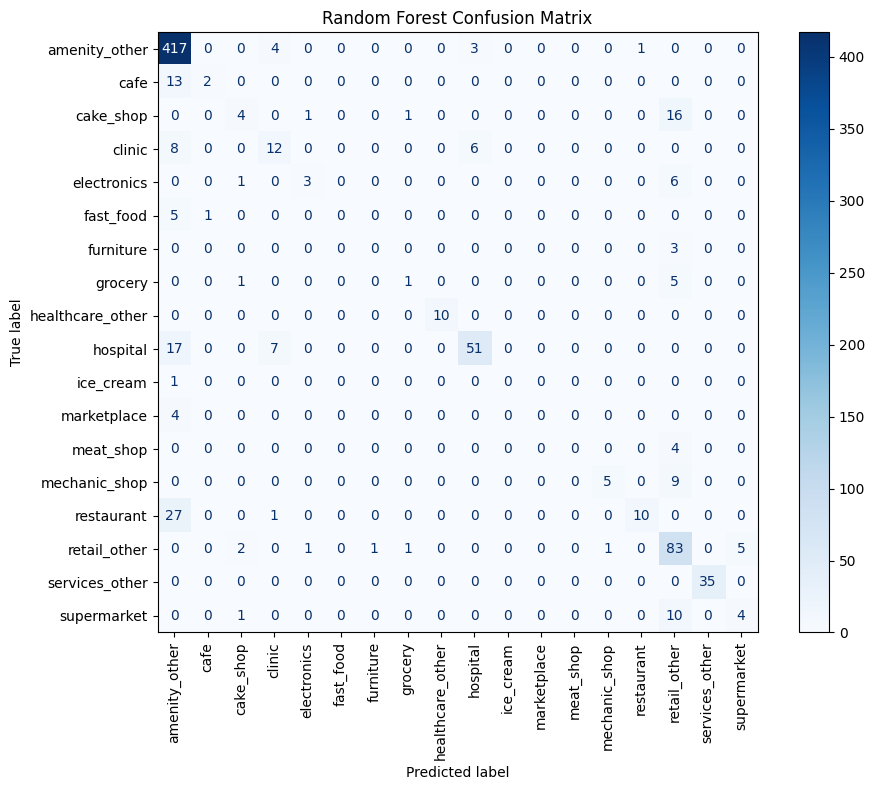

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
display.plot(ax=ax, cmap='Blues', xticks_rotation=90, colorbar=True)

plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()